## Colab 환경에서 실행 시 환경 설정

In [1]:
# 구글 드라이브의 폴더와 구글 코랩 폴더 연결
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 현재 경로 확인
!pwd

/content


In [3]:
# drive/MyDrive/Colab
%cd drive/MyDrive/Colab

/content/drive/MyDrive/Colab


#### 코랩에서 한국어 표시하기

In [ ]:
!pip install koreanize-matplotlib

In [ ]:
import koreanize_matplotlib

<hr>

<a id="lecture_index"></a>
# 🔖 ResNet 및 분류 모델 마무리

## 수업 목차
[1. 복습](#one)

[2. VGG 구조 이해 및 구현](#two)
- VGG 모델 특징
- VGG 모델 시각화
- PyTorch로 구현하기

[3. ResNet 개념 및 구현](#three)
- ResNet 모델 특징
- ResNet 구조 시각화
- 논문 분석
- PyTorch로 구현하기

[4. 사전학습 모델 활용법](#four)
- 사전학습 모델 개념
- 사전학습 모델 찾는 법
- 사전학습 모델 불러오기
- 사전학습 모델을 활용한 추론

[5. 사전학습 모델 활용 두 가지 방법](#five)
- 전이 학습

[6. 분류 모델 미니 프로젝트](#six)
- 데이터 수집 부터 모델 학습까지

## <a id='one'>1️⃣ 복습</a><br>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>

### 🧩 Quiz 1

- 이미지 분류 살펴봤고
- Alexnet
1. Dropout
2. Maxpooling
- stride = kernel size -> non-overlapping pooling
- stride < kernel size -> overlapping pooling -> 표현력 증가  
3. relu 도입
- 기울기 소실 문제 해결
4. GPU를 처음 사용
5. Local Response Normalization -> 과적합 방지용

과적합을 막기 위해 사용했던 방법들
- Dropout
- LRN
- pooling
- 데이터 증강
- (스케줄링)

기울기 소실 문제 해결
- relu

학습 속도 개선, 학습 효율 개선
- 가중치 초기화 (가우시안 분포)
- 스케줄링

데이터 증강 및 전처리
- 데이터 증강: 고정적이지 않은 변환 /양을 늘리는
- 전처리: 고정된 변환 / 규격을 맞추는
- 미리 이미지 사이즈를 전처리 규격에 맞춰서 저장해둠 -> 메모리 효율적, 연산 시간 단축


## <a id='two'>2️⃣ VGG구조 이해 및 구현</a><br>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>

### ✅ VGG 모델 특징
> VGG는 3x3 Conv 필터를 여러 번 쌓아 깊이를 늘려 성능 향상에 성공한 모델

#### 1️⃣ 3x3 Convolution을 반복해서 깊은 구조 구성
- 모든 Conv Layer는 3x3 필터, padding=1, stride=1 사용
- 여러 개를 쌓으면 receptive field가 커지면서 복잡한 패턴도 포착 가능
- 예: 3x3 2개 = 5x5, 3개 = 7x7 효과

#### 2️⃣ 층이 매우 깊은 CNN 구조
- 총 16개 레이어 (13 Conv + 3 FC)
- 모델이 깊어지면서 정교한 특징 추출 가능

#### 3️⃣ 일관된 구조와 단순한 설계
- 모든 블록이 거의 같은 패턴(Conv x2~3 → MaxPooling)
- 구조가 반복적이고 직관적이어서 구현·확장에 용이

#### 4️⃣ Feature Extractor로 많이 사용
- 단순하고 안정적인 구조 덕분에, 이후 다양한 모델의 백본(backbone)으로 자주 사용됨

#### 5️⃣ 파라미터 수가 매우 많음
- Fully Connected Layer에서 파라미터 수 폭증
- 약 138M(1억 3천만 개) → 연산량이 크고, 메모리 부담도 큼

출처: https://arxiv.org/pdf/1409.1556

### VGG 모델 시각화

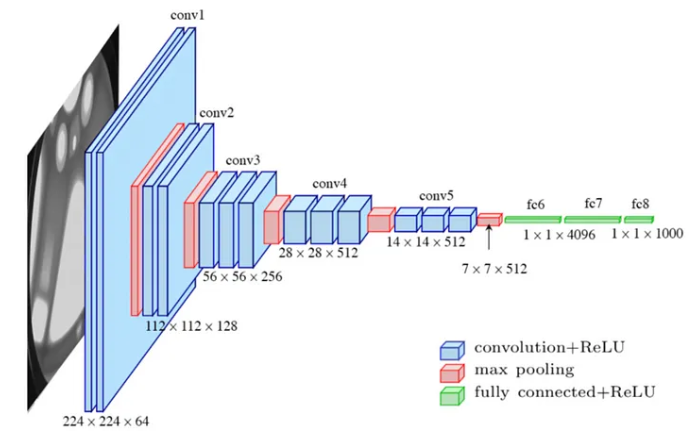

### 논문 분석

#### 용어
> receptive field -> kernel size <br>

#### 데이터 전처리
- Mean substraction (정규화)

#### 데이터 증강
- [Multi-scale traning] 원본 비율 유지한 채로(짧은쪽을 고정하지만 그 길이는 랜덤 선택{256, 384, ...}) Resize -> 랜덤 crop (고정 사이즈)
- Horizontal flip (수평 뒤집기)
- Random RGB Color shift (랜덤하게 밝기 조절)

#### 학습 세부 사항

- batch_size: 256
- SGD
1) momentum: 0.9
2) weight decay: 0.0005
2) learning rate: 0.01 (총 3번 학습률 감소 예정)
- dropout: 0.5
- epoch: 74

### PyTorch로 VGG 구현

In [5]:
from torch.utils.data import DataLoader, Dataset, random_split, Subset
from torchvision import transforms
from torchvision.datasets import CIFAR10

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(0.5), # 50% 확률로 좌우 반전
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02), # 밝기, 대비, 채도, 색조 조절
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])
])
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])
])

train_dataset = CIFAR10(root='./data', train=True, download=True, transform=train_transform)
val_dataset = CIFAR10(root='./data', train=False, download=True, transform=val_transform)
# train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

subset_indices1 = list(range(200))
subset_indices2 = list(range(20))

train_dataset = Subset(train_dataset, subset_indices1)
val_dataset = Subset(val_dataset, subset_indices2)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [10]:
import torch.nn as nn

class VGG16(nn.Module):
    def __init__(self):
        super(VGG16, self).__init__()
        self.feature_extractor = nn.Sequential(
            # conv1
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, stride=1, padding=1), # 224 x 224
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1), # 224 x 224
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # 112 x 112
            # conv2
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1), # 112 x 112
            nn.ReLU(),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, stride=1, padding=1), # 112 x 112
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # 56 x 56
            # conv3
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=1), # 56 x 56
            nn.ReLU(),
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, stride=1, padding=1), # 56 x 56
            nn.ReLU(),
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, stride=1, padding=1), # 56 x 56
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # 28 x 28
            # conv4
            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, stride=1, padding=1), # 28 x 28
            nn.ReLU(),
            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1), # 28 x 28
            nn.ReLU(),
            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1), # 28 x 28
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # 14 x 14
            # conv5
            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1), # 14 x 14
            nn.ReLU(),
            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1), # 14 x 14
            nn.ReLU(),
            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1), # 14 x 14
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) # 7 x 7
        ) # 16, 3, 224, 224 -> 16, 512, 7, 7
        self.classifier = nn.Sequential(
            # Flatten
            nn.Flatten(),
            # FC1 # 16, 512x7x7
            nn.Linear(512*7*7, 4096),
            nn.ReLU(),
            nn.Dropout(0.5),
            # FC2
            nn.Linear(4096, 4096),
            nn.ReLU(),
            nn.Dropout(0.5),
            # FC3
            nn.Linear(4096, 1000)
        )

    def forward(self, x):
      x = self.feature_extractor(x)
      x = self.classifier(x)

      return x

In [17]:
transform = transforms.Compose([
    transforms.Resize((100, 100))
])

In [6]:
img, label = next(iter(train_loader))
img2 = transform(img)

In [7]:
img.shape, img2.shape

torch.Size([64, 3, 224, 224])

In [14]:
conv = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding=1, stride=1)

In [15]:
output = conv(img)

In [16]:
output.shape

torch.Size([64, 64, 224, 224])

In [101]:
class VGG16(nn.Module):
    def __init__(self):
        super(VGG16, self).__init__()
        self.layer_config = [64, 64, 'M',
                             128, 128, 'M',
                             256, 256, 256, 'M',
                             512, 512, 512, 'M',
                             512, 512, 512, 'M']
        self.feature_extractor = self.conv_block()
        self.classifier = nn.Sequential(
            # Flatten
            nn.Flatten(),
            nn.Linear(512*7*7, 4096),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(4096, 4096),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(4096, 1000)
        )

    def conv_block(self):
      layers = []
      in_ch = 3
      for i in self.layer_config:
        if i == 'M':
          layers += [nn.MaxPool2d(kernel_size=2, stride=2)]
        else:
          layers += [nn.Conv2d(in_channels=in_ch, out_channels=i, kernel_size=3, padding=1),
                     nn.ReLU()]
          in_ch = i

      return nn.Sequential(*layers)

    def foward(self, x):
      x = self.feature_extractor(x)
      x = self.classifier(x)
      return

In [102]:
vgg16 = VGG16()

In [33]:
def test(*args, **kwargs):
  return args, kwargs

In [24]:
test(1,2,3, k1=4, k2=5, k3=6)

((1, 2, 3), {'k1': 4, 'k2': 5, 'k3': 6})

In [36]:
test(*{'k1': 4, 'k2': 5, 'k3': 6})

(('k1', 'k2', 'k3'), {})

In [37]:
test(**{'k1': 4, 'k2': 5, 'k3': 6})

((), {'k1': 4, 'k2': 5, 'k3': 6})

In [103]:
def test(*args, **kwargs):
  a, b, c = args
  return a**2 + b*3 + c

In [104]:
t = test(*[1,2,3]) # unpack

In [106]:
1**2 + 2*3 + 3

10

In [105]:
t

10

### Multi scale training

In [10]:
from tqdm import tqdm
from torchvision import transforms
import random

In [12]:
image_sizes = [256, 384, 512]

In [20]:
random.choice(image_sizes)

256

In [9]:
from torch.utils.data import DataLoader, Dataset, random_split, Subset
from torchvision import transforms
from torchvision.datasets import CIFAR10

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(0.5), # 50% 확률로 좌우 반전
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02), # 밝기, 대비, 채도, 색조 조절
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])
])
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])
])

train_dataset = CIFAR10(root='./data', train=True, download=True, transform=train_transform)
val_dataset = CIFAR10(root='./data', train=False, download=True, transform=val_transform)
# train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

subset_indices1 = list(range(200))
subset_indices2 = list(range(20))

train_dataset = Subset(train_dataset, subset_indices1)
val_dataset = Subset(val_dataset, subset_indices2)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

100%|██████████| 170M/170M [00:03<00:00, 48.6MB/s]


In [ ]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02),
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])
])

In [3]:
from tqdm import tqdm

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=10):
    model.to(device)

    total_train_losss = []
    total_val_loss = []
    total_train_acc = []
    total_val_acc = []

    for epoch in range(epochs):
        # 학습 단계
        model.train()
        total_loss, correct, total = 0, 0, 0

        for images, labels in tqdm(train_loader, desc="Training"):
            new_size = random.choice(image_sizes)
            new_transform = transforms.Compose([
              transforms.RandomHorizontalFlip(0.5),
              transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02),
              transforms.Resize(new_size),
              transforms.CenterCrop(224),
              transforms.ToTensor(),
              transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])
            ])

            train_loader.dataset.set_transform(new_transform)

            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

        train_loss = total_loss / len(train_loader)
        train_acc = correct / total * 100
        total_train_losss.append(train_loss)
        total_train_acc.append(train_acc)

        # 검증 단계
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc='Validation'):
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= len(val_loader)
        val_acc = val_correct / val_total * 100
        total_val_loss.append(val_loss)
        total_val_acc.append(val_acc)

        scheduler.step()

        print(f"[{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    return total_train_losss, total_val_loss, total_train_acc, total_val_acc

  0%|          | 1/1000 [00:01<16:41,  1.00s/it]

0


  0%|          | 2/1000 [00:02<16:46,  1.01s/it]

1


  0%|          | 3/1000 [00:03<16:42,  1.01s/it]

...

  1%|▏         | 14/1000 [00:14<16:31,  1.01s/it]

13


  2%|▏         | 15/1000 [00:15<16:37,  1.01s/it]

14


KeyboardInterrupt: 

## <a id='three'>3️⃣ ResNet 개념 및 구현</a><br>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>

### ✅ ResNet 모델 특징
> 배경: 'Layer를 깊게 쌓으면 쌓을 수록 성능이 좋아진다'라는 기대가 있었음. <br>
> 처음에 16층, 19층, 22층까지 좋은 성능을 보였지만 그 이후 더 깊은 Layer를 쌓는 시도에서 빠질 수 없는 문제가 있었음. <br>
> 바로 'Gradient Vanishing/Exploding'문제. 이 문제가 발생하지 않더라도 과적합 문제 혹은 성능이 오히려 저하되는 문제가 있었음

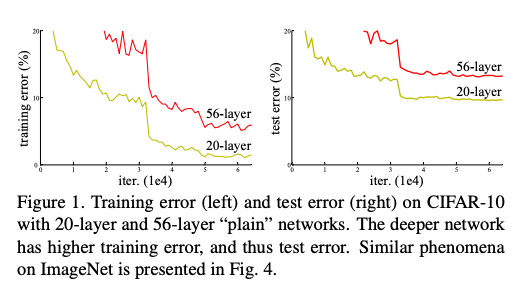

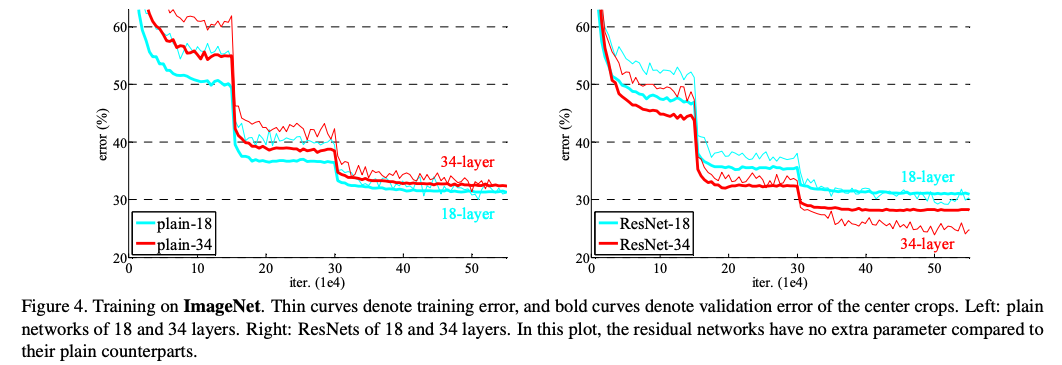

#### 1️⃣ Shortcut connection (Skip connection)
- 이전 층의 계산 결과를 현재 층의 계산 결과와 더해주는 경로
- 학습을 하면서 layer가 깊어지면서 미분 값이 작아지는 것을 막아주는 방법

#### 2️⃣ Residual Learning  
- Shortcut connection의 구현으로 입력 x의 일부를 그대로 유지하여 그 다음 레이어에 전달하기 때문에 입력값이 이미 정답과 가까운 상태를 함
- 따라서 좀 더 줄어든 차이(입력값과 출력값의 부족한 차이)를 학습하면 되는 구조로 변환됨 (잔차 학습)

#### 3️⃣ 기존의 CNN 계열의 네트워크보다 훨씬 더 깊어진 네트워크 (34 ~ 152층까지 성공)
- 실험적으로 152층에서도 안정적인 학습 성능을 보여주었음
- residual learning을 함으로써 layer가 깊어짐에 따라 성능도 비례하여 증가함

#### 4️⃣ 1x1 Convolution 활용
- 채널수를 조절하면서 이미지 크기를 절반으로 줄이는 연산 (pooling + 채널 변환 효과)
- 연산량 및 파라미터를 대폭 줄이면서 이미지 크기는 동일하게 유지 -> 비선형적인 표현력 증가, 더 많은 공간 정보 유지
```
ex) 3x3 커널 연산: in_channel=64, out_channel=64, h=54, w=54
                 => 연산량: 107,495,424 / 파라미터: 36,864
    1x1, 3x3, 1x1 연산(Bottleneck): in_channel=64, out_channel=16
                                   in_channel=16, out_channel=16
                                   in_channel=16, out_channel=64
                                   => 연산량: 8,218,624 / 파라미터: 4352
```

#### 5️⃣ Adaptive average pooling 활용
- 입력 사이즈와 출력 사이즈만 알면 자동으로 stride, kernel 사이즈를 지정하여 출력 사이즈 만들어 줌
- stride = floor(input_size/output_size)
- kernel = input_size - (output_size -1)*stride
- fc layer와 연결하기 쉬움
- 파라미터 없음
- 전역적 특징 추출 가능
- 위치 정보 손실
- detection, segmentation 같은 문제에서는 활용하는 것에는 주의가 필요

### ResNet 구조 시각화

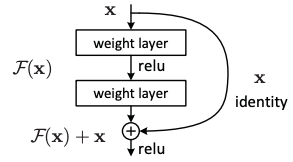

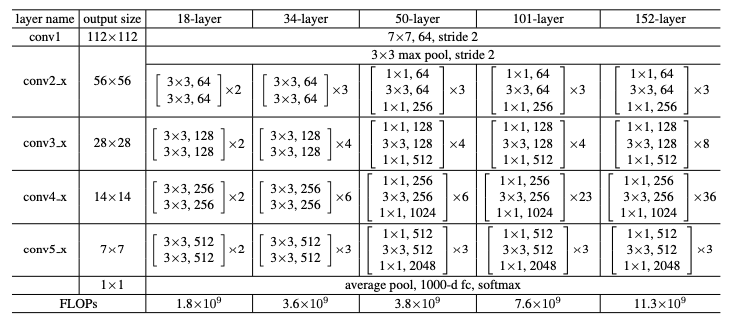

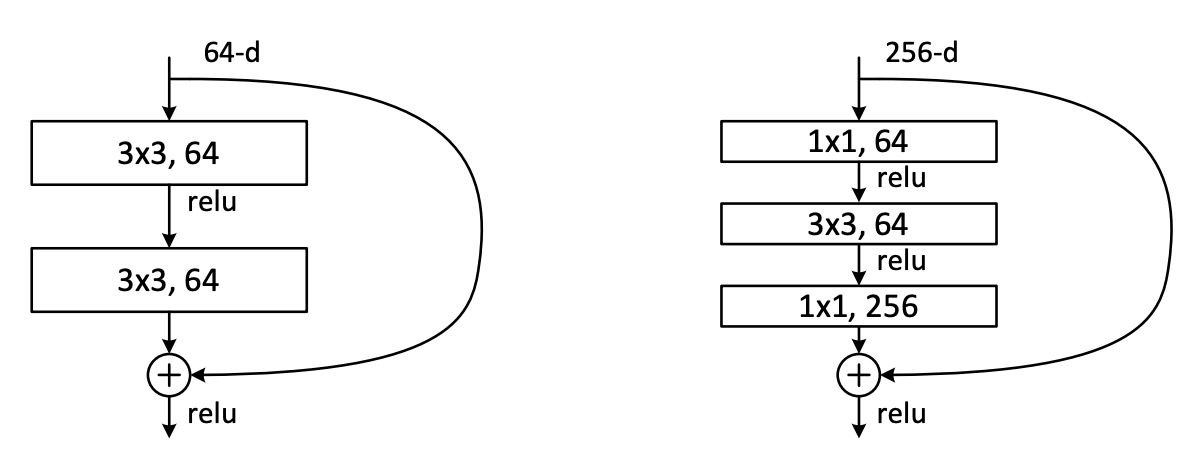

왼쪽: Building block / 오른쪽: bottleneck

구분|Building block | Bottleneck
---|---|---
모델 버전|ResNet-18, ResNet-34|ResNet-50, ResNet-101, ResNet-152
구조|Conv(3x3) -> Conv(3x3)|Conv(1x1) -> Conv(3x3) -> Conv(1x1)
목적|적당한 깊이에서 효과적|깊이를 늘려도 효율적
skip 연결|입력과 출력 shape이 같으면 identity, 다르면 projection||

✅ identity: 입력 그대로 더함 (그대로 내보내는 함수를 identity function이라고함) <br>
✅ projection: 연산이 가능한 형태로 모양을 변환함

In [71]:
t = torch.randn(1, 3, 54, 54)

In [72]:
t.shape

torch.Size([1, 3, 54, 54])

In [82]:
conv = nn.Conv2d(in_channels=3, out_channels=3, kernel_size=3, padding=1, stride=2)

In [83]:
a = conv(t)

In [84]:
a.shape

torch.Size([1, 3, 27, 27])

### Building Block, Bottleneck 구현

In [175]:
class BuildingBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(BuildingBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, stride=stride)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, stride=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.projection = None

        if stride != 1 or in_channels != out_channels:
          self.projection = nn.Sequential(
              nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, stride=stride),
              nn.BatchNorm2d(out_channels)
          )


    def forward(self, x):
      identity = x

      out = self.conv1(x) # convolution 연산이 텐서를 복사해서 연산함
      out = self.bn1(out)
      out = self.relu(out)

      out = self.conv2(out)
      out = self.bn2(out)

      if self.projection is not None:
        out = out + self.projection(identity)
        out = self.relu(out)
        return out

      out = self.relu(out + identity)
      return out

In [176]:
bb = BuildingBlock(64, 64, stride=2)

In [179]:
t = torch.randn(1, 64, 54, 54)

In [178]:
bb(t).shape

torch.Size([1, 64, 27, 27])

In [180]:
conv1 = nn.Conv2d(64, 64, kernel_size=3, padding=1, stride=2)
conv2 = nn.Conv2d(64, 64, kernel_size=1, stride=1)

In [164]:
t.shape

torch.Size([1, 64, 54, 54])

In [165]:
conv1(t).shape

torch.Size([1, 64, 27, 27])

In [181]:
conv2(t).shape

torch.Size([1, 64, 56, 56])

In [189]:
class Bottleneck:
    expand = 4
    def __init__(self, in_channels, out_channels, stride=1):
        super(Bottleneck, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, stride=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()

        self.conv3 = nn.Conv2d(out_channels, out_channels*self.expand, kernel_size=1, stride=1)
        self.bn3 = nn.BatchNorm2d(out_channels*self.expand)

        self.projection = None

        if stride != 1 or in_channels != out_channels*self.expand:
          self.projection = nn.Sequential(
              nn.Conv2d(in_channels, out_channels*self.expand, kernel_size=3, padding=1, stride=stride),
              nn.BatchNorm2d(out_channels*self.expand)
          )


    def forward(self, x):
      identity = x

      out = self.conv1(x) # convolution 연산이 텐서를 복사해서 연산함
      out = self.bn1(out)
      out = self.relu(out)

      out = self.conv2(out)
      out = self.bn2(out)
      out = self.relu(out)

      out = self.conv3(out)
      out = self.bn3(out)

      if self.projection is not None:
        out = out + self.projection(identity)
        out = self.relu(out)
        return out

      out = self.relu(out + identity)
      return out

In [184]:
bn1 = Bottleneck(256, 64)

In [187]:
bn1

In [ ]:
BottleNeck(
  (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1))
  (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (projection): Sequential(
    (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
)

### Shortcut connection의 효과

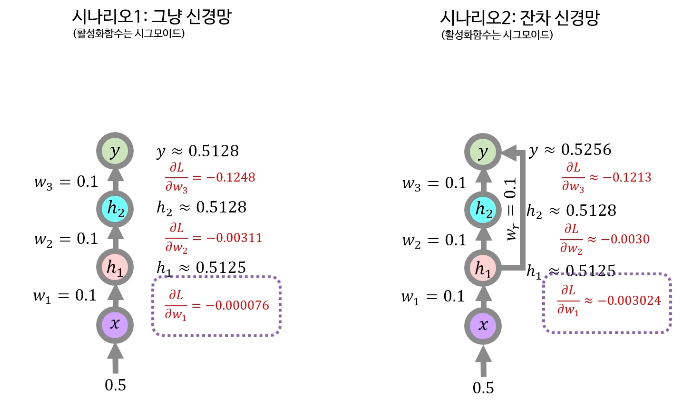

In [ ]:
0.00007797
0.00319890
0.12811816

0.00319267
0.00319261
0.12786606

In [ ]:
1. 물 500g 넣기
2. 30분 동안 끓이기
3. 소스 30g 넣기
4. 10분 동안 섞기

1. 물 500g 넣기
2. 30분 동안 끓이기

1. 물 300g 넣기  200
2. 10분 동안 끓이기  20

3. 소스 30g 넣기
4. 10분 동안 섞기

맛있니?

출처: https://www.youtube.com/watch?v=Yf_-bj2Zaq4

In [41]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# 가중치 초기화
w1 = torch.tensor(0.1, requires_grad=True)
w2 = torch.tensor(0.1, requires_grad=True)
w3 = torch.tensor(0.1, requires_grad=True)
wr = torch.tensor(0.1, requires_grad=True)
target = torch.tensor(1)

# 입력값
x = torch.tensor(0.5)

h1 = F.sigmoid(w1 * x)
h2 = F.sigmoid(w2 * h1)
y = F.sigmoid(w3 * h2 + wr*h1)

y.backward()

In [42]:
print(f'{w1.grad.item():.8f}')
print(f'{w2.grad.item():.8f}')
print(f'{w3.grad.item():.8f}')

0.00319267
0.00319261
0.12786606


In [ ]:
0.00007797
0.00319890
0.12811816

0.00319267
0.00319261
0.12786606

In [39]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# 가중치 초기화
w1 = torch.tensor(0.1, requires_grad=True)
w2 = torch.tensor(0.1, requires_grad=True)
w3 = torch.tensor(0.1, requires_grad=True)
target = torch.tensor(1)

# 입력값
x = torch.tensor(0.5)

h1 = F.sigmoid(w1 * x)
h2 = F.sigmoid(w2 * h1)
y = F.sigmoid(w3 * h2)



y.backward()

In [40]:
print(f'{w1.grad.item():.8f}')
print(f'{w2.grad.item():.8f}')
print(f'{w3.grad.item():.8f}')

0.00007797
0.00319890
0.12811816


### 논문 분석

#### 데이터 전처리

1. 표준화 (ImageNet 통계값 기준)

#### 데이터 증강

1. 짧은 변을 [256, 480] 범위로 랜덤 resize
2. 224x224 랜덤 crop
3. 좌우 반전


#### 학습 세부 사항

1. batch size: 256
2. Optimizer: SGD
- Momentum (0.9)
- Weight Decay: 0.0001
- Learning Rate: 초기 0.1 → plateau 시 1/10 감소
3. 90 epoch
4. Batch Normalization (Conv 연산 다음 / 활성화 함수 연산 전)

### PyTorch 구현

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchsummary import summary

In [237]:
class ResNet50(nn.Module):
    def __init__(self):
        super(ResNet50, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2)
        )
        self.bn1 = Bottleneck(64, 64)  # 56 x 56
        self.bn2 = Bottleneck(256, 64)
        self.bn3 = Bottleneck(256, 64) # 56 x 56

        self.bn4 = Bottleneck(256, 128, stride=2) # 28 x 28
        self.bn5 = Bottleneck(512, 128) # 28 x 28
        self.bn6 = Bottleneck(512, 128) # 28 x 28
        self.bn7 = Bottleneck(512, 128) # 28 x 28

        self.bn8 = Bottleneck(512, 256, stride=2) # 14 x 14
        self.bn9 = Bottleneck(1024, 256) # 14 x 14
        self.bn10 = Bottleneck(1024, 256) # 14 x 14
        self.b11 = Bottleneck(1024, 256) # 14 x 14
        self.bn12 = Bottleneck(1024, 256) # 14 x 14
        self.bn13 = Bottleneck(1024, 256) # 14 x 14

        self.bn14 = Bottleneck(1024, 512) # 7 x 7
        self.bn15 = Bottleneck(2048, 512) # 7 x 7
        self.bn16 = Bottleneck(2048, 512) # 7 x 7

        self.avg = nn.AdaptiveAvgPool2d((1,1))
        self.flatten = nn.Flatten(0)
        self.fc = nn.Linear(2048, 1000)

    def forward(self, x):
      x = self.conv1(x)

      x = self.bn1(x)
      x = self.bn2(x)
      x = self.bn3(x)
      x = self.bn4(x)
      x = self.bn5(x)
      x = self.bn6(x)
      x = self.bn7(x)
      x = self.bn8(x)
      x = self.bn9(x)
      x = self.bn10(x)
      x = self.bn11(x)
      x = self.bn12(x)
      x = self.bn13(x)
      x = self.bn14(x)
      x = self.bn15(x)
      x = self.bn16(x)
      x = self.avg(x)
      x = self.flatten(x) # x = x.squeeze(1, 2)
      x = self.fc(x)

      return x

In [235]:
t = torch.randn(2048,7,7)
tt = torch.randn(100, 1, 1)
flatten = nn.Flatten(0)
avg = nn.AdaptiveAvgPool2d((1,1))
fc = nn.Linear(2048, 1000)

In [236]:
flatten(tt).shape

torch.Size([100])

In [195]:
(111*2 - 217)/2

2.5

217

## <a id='four'>4️⃣ 사전학습 모델 활용법</a><br>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>

## 사전학습 모델

> 사전학습 모델(pre-trained model)은 대규모 데이터로 사전에 학습된 신경망 모델 <br>
> 일반적으로 이 모델들은 특정 작업이나 데이터셋에 최적화되기 전에, 일반적인 패턴이나 특징을 학습함

참고: https://pytorch.org/vision/stable/models.html

### 사전학습 모델 찾는 법

In [241]:
from timm import list_models # pip install timm

all_models = list_models()

In [243]:
len(all_models)

1200

### 사전학습 모델 불러오기

In [238]:
# @title
import pandas as pd
data = {
    "항목": [
        "목적", "결과", "가중치 적용", "전처리 접근", "유용한 상황", "활용 추천", "유연성",
    ],
    "get_model()": [
        "모델 구조 + 가중치 로딩",
        "nn.Module",
        '"DEFAULT" or Enum 지정',
        ".transforms() 가능",
        "표준적이고 깔끔한 사용",
        "⭐⭐⭐⭐⭐",
        "🟡 중간",
    ],
    "get_weight()": [
        "가중치 enum 객체만 가져옴",
        "Weights Enum 객체",
        "적용은 직접 해야 함",
        ".transforms() 포함",
        "가중치가 언제, 어떻게 학습되었는지 자세한 정보가 필요할 때",
        "⭐⭐⭐⭐☆",
        "🔴 낮음",
    ],
    "get_model_weights()": [
        "모델의 가중치 enum 목록 조회",
        "Enum 리스트",
        "적용은 직접 해야 함",
        "각 enum에 대해 접근 가능",
        "여러 가중치 비교 시",
        "⭐⭐⭐☆☆",
        "❌ 매우 낮음",
    ],
    "torch.hub.load()": [
        "GitHub 저장소에서 불러오기",
        "nn.Module",
        "weights='enum 단, 저장소마다 기본 가중치는 다름",
        "직접 구현 필요",
        "외부 논문/커스텀 모델 사용",
        "⭐⭐☆☆☆",
        "🚀 매우 높음",
    ],
    "클래스 방식 (models.resnet18)": [
        "모델 클래스 직접 불러오기",
        "nn.Module",
        "weights='enum'",
        "대부분 수동 구현",
        "기존 코드를 그대로 따라하거나 특정 레이어만 간단하게 수정해서 쓸 때",
        "⭐⭐⭐☆☆",
        "🟠 약간 높음",
    ],
    "Hugging Face 방식": [
        "Transformer, ViT 등 최신 모델 로딩",
        "HuggingFace 모델 객체",
        ".from_pretrained()",
        "자동 제공 (tokenizer 등)",
        "최신 모델을 불러오거나 바로 추론하거나 fine-tuning을 하고 싶을 때",
        "⭐⭐⭐⭐☆",
        "🟢 높음",
    ]
}
df1 = pd.DataFrame(data)

In [239]:
# @title
import plotly.graph_objects as go # pip install plotly / pip install --upgrade nbformat

def show_table(df, width, height):
    header = list(df.columns)
    cells = [df[col] for col in df.columns]

    fig = go.Figure(data=[go.Table(
        header=dict(values=header, fill_color='paleturquoise', align='left'),
        cells=dict(values=cells, fill_color='lavender', align='left'))
    ])

    fig.update_layout(
        autosize=True,
        margin=dict(l=10, r=10, t=10, b=10),
        width=width,
        height=height
    )
    fig.show()

In [240]:
show_table(df1, 1000, 350)

✅ enum
```
:정해진 값 외에는 바뀌지 않는 이름들의 집합
여기서 말하는 enum은 모델의 이름 집합
ex) vgg16, resnet50 등...
```

```
⭐⭐⭐⭐⭐: 실무, 연습 모두 추천 (공식 표준)
⭐⭐⭐⭐: 추천하는 방식이지만 약간의 제약/주의가 필요
⭐⭐⭐: 상황에 따라 쓰면 유용. 보조용으로 적합
⭐⭐: 고급 사용자에게 추천. 문서나 코드 구조를 분석할 수 있는 경우 사용
```

In [245]:
from torchvision.models import get_model, get_weight, get_model_weights, resnet50, ResNet50_Weights

vgg16 = get_model("vgg16", weights=None)
pretrained_vgg16 = get_model("vgg16", weights="DEFAULT")

resnet50_enum = get_weight('ResNet50_Weights.DEFAULT') # ResNet50_Weights.DEFAULT와 동일 (Enum 객체)

# accuracy 76.130%
resnet1 = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
# accuracy 80.858%
resnet2 = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
# 기본 모델 (IMAGENET1K_V2와 동일)
resnet3 = resnet50(weights=ResNet50_Weights.DEFAULT)
# 문자열로도 설정 가능
resnet4 = resnet50(weights="IMAGENET1K_V2")
# 랜덤으로 초기화된 모델 (사전학습 모델 X)
resnet5 = resnet50(weights=None)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:08<00:00, 67.7MB/s]
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:02<00:00, 35.6MB/s]
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 113MB/s]


In [249]:
resnet = get_weight('ResNet50_Weights.DEFAULT')

In [250]:
resnet.url

'https://download.pytorch.org/models/resnet50-11ad3fa6.pth'

In [253]:
len(resnet.meta['categories'])

1000

In [254]:
dir(resnet)

['__class__',
 '__doc__',
 '__eq__',
 '__hash__',
 '__module__',
 'get_state_dict',
 'meta',
 'name',
 'transforms',
 'url',
 'value',
 'verify']

In [256]:
resnet.transforms()

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [262]:
resnet.verify

<bound method WeightsEnum.verify of <enum 'ResNet50_Weights'>>

In [246]:
# repo_or_dir: Github 주소 + 태그(버전)
# model: 모델 이름
# force_reload=True -> 캐시된 모델을 가져오지 않고 최신으로 가져옴
# trust_repo: pytorch 저장소가 아닌 다른 저장소로 부터 다운 받을 때 사용
# 단, github 저장소 안에 hubconf.py 파일이 있는 경우만 다운로드 가능
resnet18 = torch.hub.load("pytorch/vision:v0.14.0", "resnet18")

Downloading: "https://github.com/pytorch/vision/zipball/v0.14.0" to /root/.cache/torch/hub/v0.14.0.zip


### 전처리 방식은 언제 적용해야 하는 걸까?

In [247]:
# @title
data = {
    "상황": [
        "모델 학습 (train)",
        "모델 추론 (inference)",
        "fine-tuning (사전학습 모델 재학습)",
        "feature 추출 용도"
    ],
    "전처리 필요 여부": [
        "🟢 꼭 필요",
        "🟢 꼭 필요",
        "🟠 필요",
        "🟠 필요"
    ],
    "이유": [
        "원래 데이터는 다양한 크기/범위를 가지므로 정규화, 리사이즈 필요",
        "학습과 동일한 데이터 분포로 넣어야 예측이 정확함",
        "base 모델이 학습한 데이터 분포 유지 필요",
        "전처리 안 하면 feature space가 일치하지 않음"
    ]
}

df2 = pd.DataFrame(data)

In [248]:
show_table(df2, 1000, 170)

#### 🛠️ Feature space
> 가중치에 의해 정의되는 feature map의 숫자 공간 <br>
> 쉽게 말해, 데이터를 이해하는 방식을 모아 놓은 공간

### 꼭 필요는 뭐고 필요는 뭘까?

> fine-tuning 또는 feature 추출을 할 때도 전처리는 필수지만, 데이터 증강 처리는 필수 보다는 선택 쪽에 가깝다

In [267]:
a = get_model_weights('resnet50')

In [268]:
for model in a:
  print(model)

ResNet50_Weights.IMAGENET1K_V1
ResNet50_Weights.IMAGENET1K_V2


In [276]:
resnet50_enum = get_weight('ResNet50_Weights.IMAGENET1K_V1')
resnet = get_model('resnet50',weights='IMAGENET1K_V1')

In [272]:
resnet50_enum.transforms()

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

### 모델 불러오기, 전처리 찾기 너무 불편한데 한 번에 하는 방법은 없나?

In [ ]:
from torchvision.models import get_model, get_weight

def load_model_with_transform(model_name, weight_name = "DEFAULT"):
    pass

### 사전학습 모델을 활용한 추론

In [295]:
weights = resnet50_enum.IMAGENET1K_V1
transform = weights.transforms()

In [318]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open('20250403/사진/bulbul.jpeg')

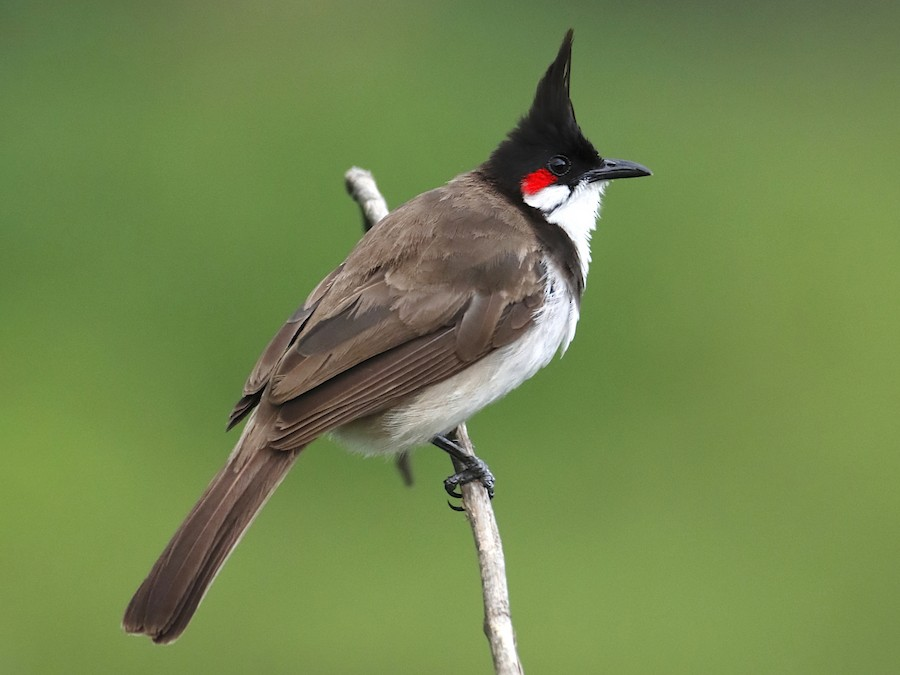

In [319]:
img

In [320]:
preprocessed_img = transform(img)

In [321]:
predict = resnet(preprocessed_img.unsqueeze(0))

In [322]:
predict.shape

torch.Size([1, 1000])

In [323]:
torch.argmax(predict).item()

600

In [324]:
weights.meta['categories'][torch.argmax(predict).item()]

'hook'

In [325]:
weights.meta['categories']

['tench',
 'goldfish',
 'great white shark',
 'tiger shark',
 'hammerhead',
 'electric ray',
 'stingray',
 'cock',
 'hen',
 'ostrich',
 'brambling',
 'goldfinch',
 'house finch',
 'junco',
 'indigo bunting',
 'robin',
 'bulbul',
 'jay',
 'magpie',
 'chickadee',
 'water ouzel',
 'kite',
 'bald eagle',
 'vulture',
 'great grey owl',
 'European fire salamander',
 'common newt',
 'eft',
 'spotted salamander',
 'axolotl',
 'bullfrog',
 'tree frog',
 'tailed frog',
 'loggerhead',
 'leatherback turtle',
 'mud turtle',
 'terrapin',
 'box turtle',
 'banded gecko',
 'common iguana',
 'American chameleon',
 'whiptail',
 'agama',
 'frilled lizard',
 'alligator lizard',
 'Gila monster',
 'green lizard',
 'African chameleon',
 'Komodo dragon',
 'African crocodile',
 'American alligator',
 'triceratops',
 'thunder snake',
 'ringneck snake',
 'hognose snake',
 'green snake',
 'king snake',
 'garter snake',
 'water snake',
 'vine snake',
 'night snake',
 'boa constrictor',
 'rock python',
 'Indian cobr

## <a id='five'>5️⃣ 사전학습 모델을 활용한 전이학습</a><br>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>

### 전이학습 (Transfer Learning)
> 사전학습된 모델의 가중치나 구조를 활용하여, 새로운 데이터 셋에 맞춰 모델을 재학습 하는 방법

#### 👆 특징 추출 (Feature Extraction)
> 사전학습된 모델의 상위 레이어를 사용해 새로운 데이터 셋에서 유용한 특징을 추출하고 마지막 레이어를 바꿔 새로운 작업을 수행하는 방법

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms, datasets
from torchvision.models import get_model, get_weight, get_model_weights, vgg16
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import CIFAR10
from torch.utils.data import Subset, DataLoader

In [9]:
# device 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. 사전학습된 모델 찾기
vgg16_enum = get_weight('VGG16_Weights.IMAGENET1K_FEATURES')

# 2. 모델 불러오기
vgg = vgg16(weights=vgg16_enum.IMAGENET1K_FEATURES)

# 3. 모델에서 feature extractor에 해당하는 layer의 미분값을 구하지 못하게 고정
for param in vgg.features.parameters():
  param.requires_grad = False # 미분값을 구하지 못하도록 설정

# 4. 출력층을 내가 원하는 대로 수정
vgg.classifier[6] = nn.Linear(4096, 10)

# 5. 옵티마이저, 손실함수, 스케줄러 등....
optimizer = optim.Adam(vgg.classifier[6].parameters(), lr=0.0001)
loss_fn = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

# 6. 데이터 불러오기

# 전처리
transform = vgg16_enum.transforms()

dataset = CIFAR10(root='data', download=True, transform=transform) # 전체 데이터
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

subset_index1 = list(range(2000))
subset_index2 = list(range(200))
train_dataset = Subset(train_dataset, subset_index1)
val_dataset = Subset(val_dataset, subset_index2)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

from tqdm import tqdm

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=10):
    model.to(device)

    total_train_losss = []
    total_val_loss = []
    total_train_acc = []
    total_val_acc = []

    for epoch in range(epochs):
        # 학습 단계
        model.train()
        total_loss, correct, total = 0, 0, 0

        for images, labels in tqdm(train_loader, desc="Training"):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

        train_loss = total_loss / len(train_loader)
        train_acc = correct / total * 100
        total_train_losss.append(train_loss)
        total_train_acc.append(train_acc)

        # 검증 단계
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc='Validation'):
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= len(val_loader)
        val_acc = val_correct / val_total * 100
        total_val_loss.append(val_loss)
        total_val_acc.append(val_acc)

        scheduler.step()

        print(f"[{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    return total_train_losss, total_val_loss, total_train_acc, total_val_acc

In [10]:
train_losss, val_loss, train_acc, val_acc = train_model(vgg,
                                                        train_loader,
                                                        val_loader,
                                                        loss_fn,
                                                        optimizer,
                                                        scheduler)

Validation: 100%|██████████| 7/7 [00:01<00:00,  4.15it/s]


[1/10] Train Loss: nan, Train Acc: 10.20% | Val Loss: nan, Val Acc: 8.50%


Validation: 100%|██████████| 7/7 [00:01<00:00,  4.82it/s]


[2/10] Train Loss: nan, Train Acc: 10.20% | Val Loss: nan, Val Acc: 8.50%


Validation: 100%|██████████| 7/7 [00:01<00:00,  4.62it/s]


...

[5/10] Train Loss: nan, Train Acc: 10.20% | Val Loss: nan, Val Acc: 8.50%


Validation: 100%|██████████| 7/7 [00:01<00:00,  4.56it/s]


[6/10] Train Loss: nan, Train Acc: 10.20% | Val Loss: nan, Val Acc: 8.50%


Training:  37%|███▋      | 23/63 [00:05<00:09,  4.01it/s]


KeyboardInterrupt: 

## 디버깅

#### 학습 루프 밖에서 디버깅

In [ ]:
def debug_nan(model, inputs, targets):
    outputs = model(inputs)

    print("Outputs contain NaN: ", torch.isnan(outputs).any().item())

    print("Prediction dtype: ", outputs.dtype)
    print("Sample Prediction: ", outputs[:5])

    print("Targets dtype: ", targets.dtype)
    print("Sample targets: ", targets[:5])

    loss_fn = nn.CrossEntropyLoss()
    loss = loss_fn(outputs, targets)
    print("Loss value: ", loss.item())

inputs, targets = next(iter(train_loader))
inputs, targets = inputs.to(device), targets.to(device)

Outputs contain NaN:  True
Prediction dtype:  torch.float32
Sample Prediction:  tensor([[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]],
       grad_fn=<SliceBackward0>)
Targets dtype:  torch.int64
Sample targets:  tensor([3, 7, 3, 0, 5])
Loss value:  nan


#### 학습 도중 디버깅

In [ ]:
class NaNDebbuger:
    def __init__(self, model, verbose=True):
        self.model = model
        self.verbose = verbose

    def check_loss(self, loss, outputs=None, targets=None, mode=None, step=None):
        pass
    def check_input(self, inputs=None, mode=None, step=None):
        pass

### 중간 출력값 디버깅

#### ✌️ 미세 조정 (Fine-tuning)
> 전체 레이어의 파라미터를 다시 재학습 하거나 일부 레이어를 제외하여, 새로운 데이터 셋을 잘 예측 할 수 있도록 학습하는 방법

In [ ]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader, random_split

# 장치 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 사전학습된 VGG16 모델 불러오기
model = models.vgg16(weights='VGG16_Weights.IMAGENET1K_V1')

## <a id='six'>6️⃣ 분류 모델 미니 프로젝트</a><br>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>